In [1]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *



In [46]:
from geopy.distance import great_circle
from geopy.point import Point
def get_points_on_line(lat1, lon1, lat2, lon2, num_points):
    """
    Calculate points along a great circle line between two lat/lon coordinates
    using geopy library
    
    Args:
        lat1: Starting latitude in degrees
        lon1: Starting longitude in degrees
        lat2: Ending latitude in degrees
        lon2: Ending longitude in degrees
        num_points: Number of points to generate (including start and end)
    
    Returns:
        Tuple of three lists: (latitudes, longitudes, distances_meters)
    """
    start = Point(lat1, lon1)
    end = Point(lat2, lon2)
    
    # Calculate total distance
    total_distance = great_circle(start, end).meters
    
    # Calculate bearing from start to end
    import math
    lat1_rad = math.radians(lat1)
    lat2_rad = math.radians(lat2)
    lon_diff = math.radians(lon2 - lon1)
    
    x = math.sin(lon_diff) * math.cos(lat2_rad)
    y = math.cos(lat1_rad) * math.sin(lat2_rad) - math.sin(lat1_rad) * math.cos(lat2_rad) * math.cos(lon_diff)
    bearing = math.degrees(math.atan2(x, y))
    
    lats = []
    lons = []
    distances = []
    
    for i in range(num_points):
        fraction = i / (num_points - 1) if num_points > 1 else 0
        distance = total_distance * fraction
        
        # Calculate destination point given distance and bearing
        destination = great_circle(meters=distance).destination(start, bearing)
        lats.append(destination.latitude)
        lons.append(destination.longitude)
        distances.append(distance)
    
    return lats, lons, distances

In [3]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='scavenger',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=4)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p scavenger
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_analysis/bin/python -m distributed.cli.dask_worker tcp://172.16.3.125:44938 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.125:44938,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


### Load in data

In [4]:
expt_datafiles = collect_tracer_files(model="CM4Xp125")
del expt_datafiles["spinup"]
expt_datafiles.keys()

dict_keys(['forced', 'control'])

In [5]:
#note to self: i'm choosing to do it this way because its a regular grid south of 60°N anyways. 
def zonal_volume_weighted_average(ds):
    weights = (ds.thkcello * ds.areacello * ds.wet ).where(ds.wet > 0)
    weights = weights.where(weights > 0)
    weighted_ds = (ds.drop_vars(["thkcello"]) * weights).sum(["xh"], skipna = True) / weights.sum(["xh"], skipna = True)
    return weighted_ds

In [6]:
ds = read_tracer_and_zos_from_budget(expt_datafiles["forced"][1])

In [7]:
latmin, latmax = -90, -40 
lonmin, lonmax = -150 - 39, -140 # a ross sea section 

In [88]:
# New York to London
wedell_lat, wedell_lon =  -76.1734, -57.5786
open_lat, open_lon =   -55.1189, -33.6911

In [89]:
lats, lons, distance = get_points_on_line(wedell_lat, wedell_lon, open_lat, open_lon, 200)

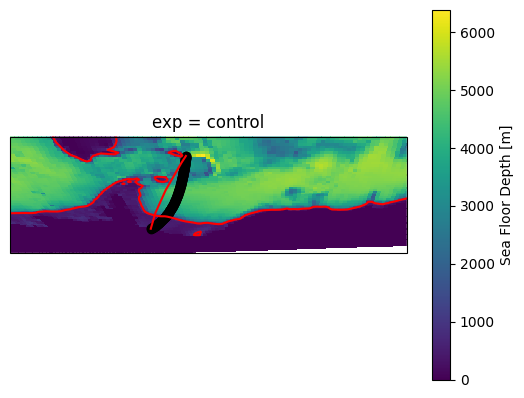

In [90]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.Robinson()))

ds.deptho.plot(x = "geolon", y = "geolat", transform = ccrs.PlateCarree())
ds.deptho.plot.contour(x = "geolon", y = "geolat", levels = [1000], colors = "r", transform = ccrs.PlateCarree())
plt.plot((wedell_lon, open_lon), (wedell_lat, open_lat), c = "red", transform = ccrs.PlateCarree())

plt.scatter(lons, lats, c = "k", transform = ccrs.PlateCarree())

ax.set_extent((-90, 40, -80, -50))

In [101]:
ds_locs = xr.Dataset()
ds_locs["lon"] = xr.DataArray(
    data=lons, dims=("locations")
)
ds_locs["lat"] = xr.DataArray(data=lats, dims=("locations"))

regridder = xe.Regridder(ds, ds_locs, "bilinear", locstream_out=True)

In [102]:
N = 125; H = 7000; eta = 25 #N must be odd to get an even number of faces
z_i = make_tanh_grid(N = N, H = H, eta = eta)
                                     #np.arange(-6500, 251, 250)
z_l = (z_i[1:] + z_i[0:-1]) / 2


In [103]:
ds_zon_ts_dict = {}
for key in expt_datafiles.keys():
    datafiles = expt_datafiles[key]
    ds_zons = []
    for (t, file) in enumerate(datafiles): 
        if t % 5 == 0:
            print(key, ":", file)
    
        ds = read_tracer_and_zos_from_budget(file)
        
        ds["rho2"] = ds.sigma2_l * xr.where(ds.thkcello.fillna(0.0) > 0.0, 1, 0) 
        ds["rho2"] = ds["rho2"].where(ds["rho2"] > 0)
        ds["rho2"].attrs.update({
        "cell_methods": ds["thetao"].attrs["cell_methods"],
        "standard_name": "sea_water_potential_density",
        "units": "kg / m^3",
        "description": "Potential Density references to 2000 dbar"
        })
        
        ds_remap = remap_sigma_to_depth(ds.where(ds.wet > 0), z_i = z_i, z_l = z_l)
        ds_remap = update_thermodynamic_variables(ds_remap, zname = "z_l")
        
        ds_zon_avg = regridder(ds_remap).compute()

        ds_zons += [1 * ds_zon_avg]

    ds_zon_ts = xr.concat(ds_zons, dim = "time").sortby("time")
    ds_zon_ts_dict[key] = 1. * ds_zon_ts
    
ds_zon_ts_list = [ds_zon_ts_dict[dkey].expand_dims(exp=[dkey]) for dkey in ds_zon_ts_dict.keys()]
combined_zon_ts_ds = xr.concat(ds_zon_ts_list, dim="exp")
combined_zon_ts_ds = combined_zon_ts_ds.assign_coords({"distances": distance})


forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_1850-1854.zarr
forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_1875-1879.zarr
forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_1900-1904.zarr
forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_1925-1929.zarr
forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_1950-1954.zarr
forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_1975-1979.zarr
forced : /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/tracers_sigma2_1p5/CM4Xp125_historical_tracers_sigma2_2000-2004.zarr
forced

In [116]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"SO_Weddell_section_Tracer_Zonal_sigma2.nc"
print(f"Saving to", ": ", savename)
combined_zon_ts_ds.to_netcdf(savename)

Saving to :  /vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/SO_Weddell_section_Tracer_Zonal_sigma2.nc


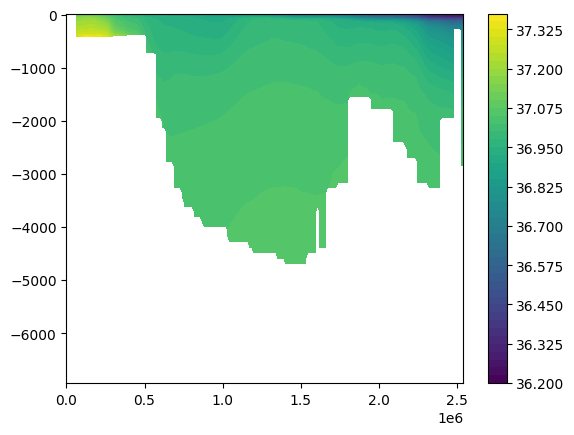

In [113]:
plt.contourf(combined_zon_ts_ds.distances, combined_zon_ts_ds.z_l, combined_zon_ts_ds.rho2.sel(exp = "control").mean("time"), levels = 50)
plt.colorbar()

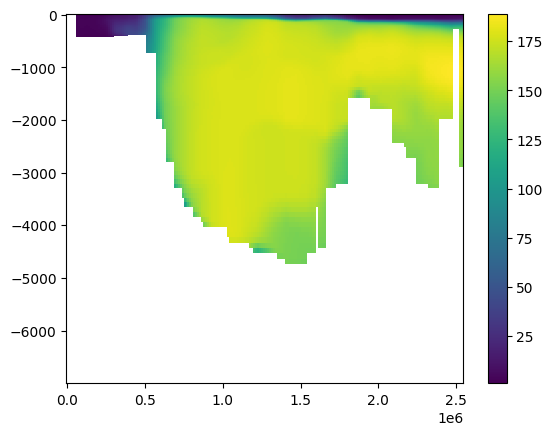

In [109]:
plt.pcolormesh(combined_zon_ts_ds.distances, combined_zon_ts_ds.z_l, combined_zon_ts_ds.agessc.sel(exp = "control").mean("time"))
plt.colorbar()

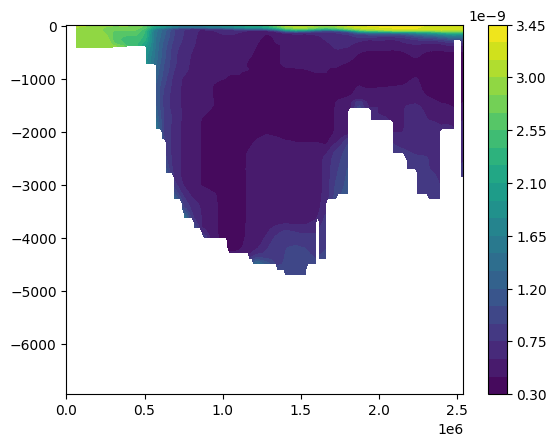

In [111]:
plt.contourf(combined_zon_ts_ds.distances, combined_zon_ts_ds.z_l, combined_zon_ts_ds.cfc11.sel(exp = "control").mean("time"), levels=25)
plt.colorbar()

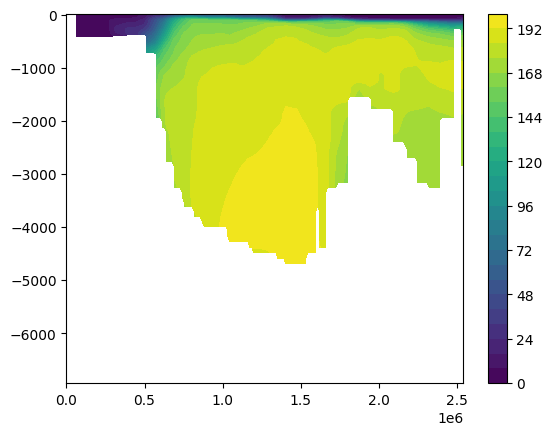

In [115]:
plt.contourf(combined_zon_ts_ds.distances, combined_zon_ts_ds.z_l, combined_zon_ts_ds.agessc.sel(exp = "forced").mean("time"), levels=25)
plt.colorbar()

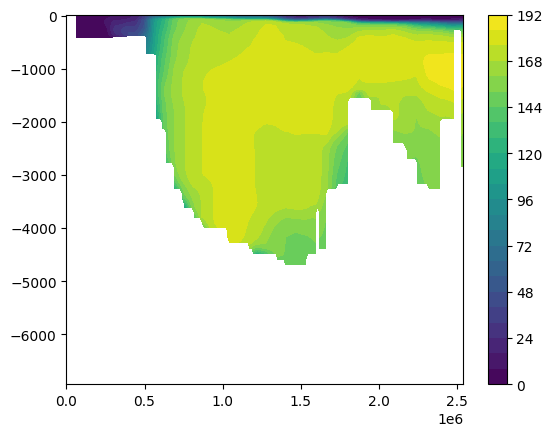

In [110]:
plt.contourf(combined_zon_ts_ds.distances, combined_zon_ts_ds.z_l, combined_zon_ts_ds.agessc.sel(exp = "control").mean("time"), levels=25)
plt.colorbar()

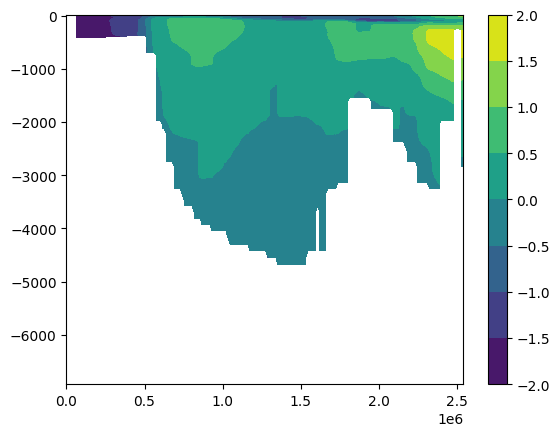

In [99]:
plt.contourf(combined_zon_ts_ds.distances, combined_zon_ts_ds.z_l, combined_zon_ts_ds.ct.sel(exp = "control").mean("time"))
plt.colorbar()

In [ ]:
ds_zon_ts_tmp = combined_zon_ts_ds.sel(exp = "control")
fig, axes = plt.subplots(2, 2, figsize = (15, 5))
ax = axes.flatten()
ds_zon_ts_tmp.mean("time")["rho2"].T.plot.contourf(ax = ax[0],y = "z_l", x = "geolat", levels = 21, vmin = 36, vmax = 37.4)
ds_zon_ts_tmp.mean("time")["ct"].T.plot.contourf(ax = ax[1],y = "z_l", x = "geolat", levels = 21, vmax = 15, vmin = -3)
ds_zon_ts_tmp.mean("time")["sa"].T.plot.contourf(ax = ax[2],y = "z_l", x = "geolat", levels = 21, vmax = 36, vmin = 34)
ds_zon_ts_tmp.mean("time")["cfc11"].T.plot.contourf(ax = ax[3], y = "z_l", x = "geolat", levels = 21, vmax = 1e-9)

In [ ]:
ds_zon_ts_tmp = combined_zon_ts_ds.sel(exp = "control")
fig, axes = plt.subplots(2, 2, figsize = (15, 5))
ax = axes.flatten()
ds_zon_ts_tmp.mean("time")["rho2"].T.plot.contourf(ax = ax[0],y = "z_l", x = "geolat", levels = 21, vmin = 36, vmax = 37.4)
ds_zon_ts_tmp.mean("time")["ct"].T.plot.contourf(ax = ax[1],y = "z_l", x = "geolat", levels = 21, vmax = 15, vmin = -3)
ds_zon_ts_tmp.mean("time")["sa"].T.plot.contourf(ax = ax[2],y = "z_l", x = "geolat", levels = 21, vmax = 36, vmin = 34)
ds_zon_ts_tmp.mean("time")["cfc11"].T.plot.contourf(ax = ax[3], y = "z_l", x = "geolat", levels = 21, vmax = 1e-9)

In [ ]:
ds_zon_ts_tmp = combined_zon_ts_ds.sel(exp = "forced")
fig, axes = plt.subplots(2, 2, figsize = (15, 5))
ax = axes.flatten()
ds_zon_ts_tmp.mean("time")["rho2"].T.plot.contourf(ax = ax[0],y = "z_l", x = "geolat", levels = 21, vmin = 36, vmax = 37.4)
ds_zon_ts_tmp.mean("time")["ct"].T.plot.contourf(ax = ax[1],y = "z_l", x = "geolat", levels = 21, vmax = 15, vmin = -3)
ds_zon_ts_tmp.mean("time")["sa"].T.plot.contourf(ax = ax[2],y = "z_l", x = "geolat", levels = 21, vmax = 36, vmin = 34)
ds_zon_ts_tmp.mean("time")["cfc11"].T.plot.contourf(ax = ax[3], y = "z_l", x = "geolat", levels = 21, vmax = 1e-9)